# Employee Data Analysis (EDA)

**Author:** Aditya Kumar

**Project:** Exploratory Data Analysis

**Date:** 17 July 2026

## Project Objective
Analyze employee data to identify salary trends, missing values, outliers, and business insights.

**Tools Used**
- Python
- Pandas
- Matplotlib
- Seaborn

## Project Contents Structure
Employee Data Analysis

1. Import Libraries

2. Load Dataset

3. Data Understanding
   - head()
   - shape
   - info()
   - describe()
   - missing values
   - duplicates

4. Data Cleaning
   - Handle Missing Values
   - Handle Duplicates
   - Handle Outliers

5. Univariate Analysis
   - Histogram
   - Boxplot
   - Countplot

6. Bivariate Analysis
   - Scatter Plot
   - Bar Plot

7. Multivariate Analysis
   - Pairplot

8. Correlation Analysis
   - Heatmap

9. Business Insights

10. Recommendations



# Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [24]:
df = pd.read_excel("employee_data.xlsx")

# Data Understanding

In this section, we explore the dataset to understand its structure, data types, summary statistics, and identify missing values before performing further analysis.

In [25]:
df.head()   # to view the first five rows

,Employee_ID,Name,Age,Gender,Department,City,Experience,Salary,Performance
0,1,Priya,28.0,Male,IT,Hyderabad,3,80649.0,2.8
1,2,Amit,38.0,Male,IT,Hyderabad,13,113988.0,3.8
2,3,Rahul,35.0,Female,HR,Mumbai,13,105859.0,4.4
3,4,Rohit,35.0,Male,HR,Mumbai,8,79527.0,2.8
4,5,Rohit,40.0,Male,Marketing,Hyderabad,11,96833.0,3.8


In [26]:
df.tail()  # to view the last five rows

,Employee_ID,Name,Age,Gender,Department,City,Experience,Salary,Performance
495,496,Neha,34.0,Female,Marketing,Hyderabad,4,73574.0,3.2
496,497,Vikas,25.0,Female,HR,Bengaluru,2,55196.0,2.5
497,498,Vikas,25.0,Male,HR,Delhi,3,61296.0,4.7
498,499,Rohit,37.0,Female,HR,Mumbai,15,117387.0,4.7
499,500,Rohit,30.0,Female,Marketing,Hyderabad,1,54528.0,4.5


In [27]:
df.shape   # to know the shape

(500, 9)

In [28]:
df.info()  # data set information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  500 non-null    int64  
 1   Name         500 non-null    object 
 2   Age          499 non-null    float64
 3   Gender       500 non-null    object 
 4   Department   499 non-null    object 
 5   City         500 non-null    object 
 6   Experience   500 non-null    int64  
 7   Salary       499 non-null    float64
 8   Performance  500 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 35.3+ KB


In [29]:
df.describe()  # stastical summary

,Employee_ID,Age,Experience,Salary,Performance
count,500.000000,499.000000,500.000000,499.000000,500.000000
mean,250.500000,33.675351,7.796000,89654.629259,3.753000
std,144.481833,5.268190,4.680406,29413.007662,0.717915
min,1.000000,22.000000,0.000000,44135.000000,2.500000
25%,125.750000,29.000000,4.000000,69837.000000,3.100000
50%,250.500000,34.000000,8.000000,88640.000000,3.800000
75%,375.250000,38.000000,12.000000,106232.500000,4.400000
max,500.000000,45.000000,15.000000,381102.000000,5.000000


In [30]:
df.isnull().sum() # to know the no of missing value in each column

Employee_ID    0
Name           0
Age            1
Gender         0
Department     1
City           0
Experience     0
Salary         1
Performance    0
dtype: int64

# Data Cleaning

In [31]:
df.duplicated()  #to check duplicate row

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [32]:
df.duplicated().sum() # for finding duplicate row

np.int64(0)

In [33]:
df = df.drop_duplicates() # used because to remove duplicates

In [47]:
df.duplicated().sum()  # to verify it

np.int64(0)

In [45]:
df.isnull().sum()[df.isnull().sum() > 0] #display only column with missing value

Series([], dtype: int64)

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].mean()) # filling missing value with mean

In [36]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0]) #fill with mode

In [40]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median()) # fill with median

In [42]:
df = df.dropna() # deleting missing row

# To Detect Outliers

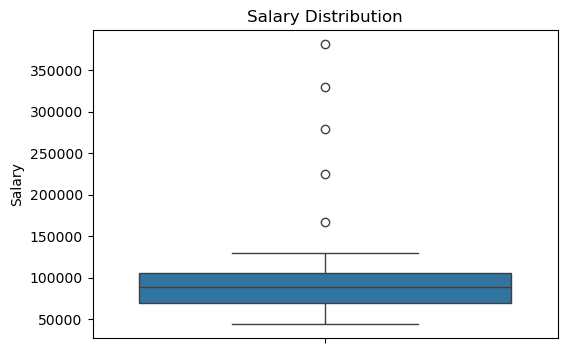

In [48]:


plt.figure(figsize=(6,4))

sns.boxplot(data=df, y="Salary")

plt.title("Salary Distribution")

plt.show()

#  Outlier Detection using IQR Method

## Objective

The objective of this section is to identify potential outliers in the Salary column using the Interquartile Range (IQR) method.

In [49]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 69837.0
Q3: 106232.5
IQR: 36395.5
Lower Limit: 15243.75
Upper Limit: 160825.75


In [50]:

outliers = df[
    (df["Salary"] < lower_limit) |
    (df["Salary"] > upper_limit)
]

outliers

,Employee_ID,Name,Age,Gender,Department,City,Experience,Salary,Performance
316,317,Anjali,38.0,Female,Finance,Delhi,15,381102.0,4.3
319,320,Rahul,33.0,Female,Sales,Bengaluru,5,224937.0,3.0
354,355,Rohit,28.0,Female,HR,Delhi,3,166467.0,2.8
415,416,Neha,43.0,Male,Sales,Mumbai,13,329340.0,3.0
416,417,Neha,31.0,Female,IT,Bengaluru,6,279261.0,3.1


## Removing Outliers

After identifying the outliers, we can remove them if they are found to be incorrect or caused by data entry errors.

In [51]:
df_clean = df[
    (df["Salary"] >= lower_limit) &
    (df["Salary"] <= upper_limit)
]

## Observation

A new dataframe named `df_clean` was created after removing the potential outliers. The original dataset remains unchanged.

## Business Insight

Removing incorrect outliers helps improve data quality and prevents extreme values from affecting business analysis. However, genuine business values should not be removed without proper investigation.

In [52]:
df_clean.shape

(494, 9)

## 6. Univariate Analysis
## Objective

Univariate Analysis is used to analyze a single variable at a time. 

# In this we will read three plot
histogram,
boxplot,
countplot


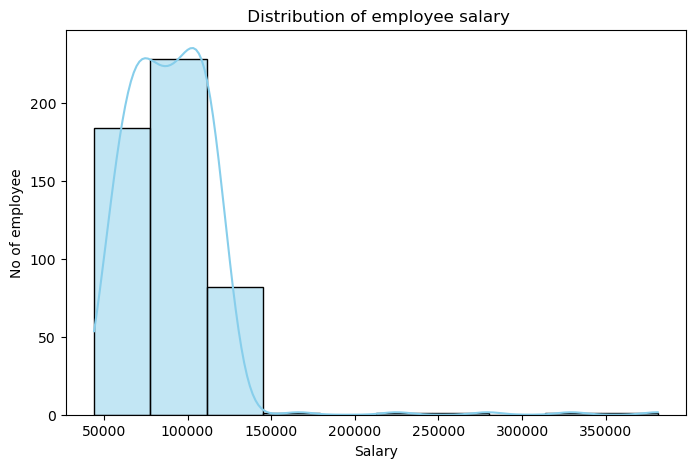

In [53]:
# 1 Salary Distribution (histogram)

plt.figure(figsize=(8,5))
sns.histplot(data = df,x="Salary",bins=10,kde=True,color="skyblue")
plt.title(" Distribution of employee salary")
plt.xlabel("Salary")
plt.ylabel("No of employee")

plt.show()


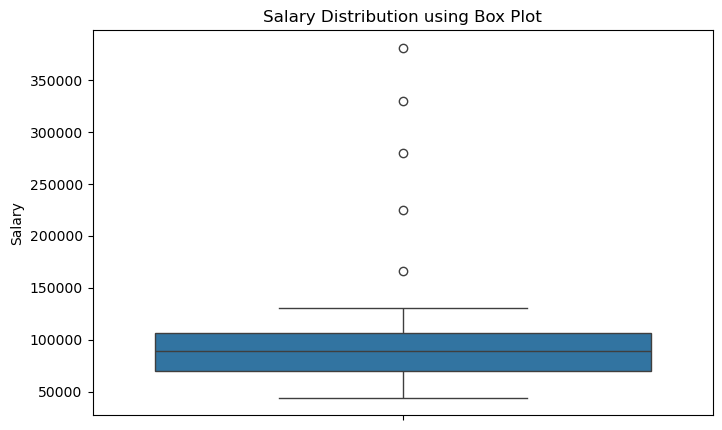

In [55]:
# using box plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Salary"
)

plt.title("Salary Distribution using Box Plot")
plt.ylabel("Salary")

plt.show()

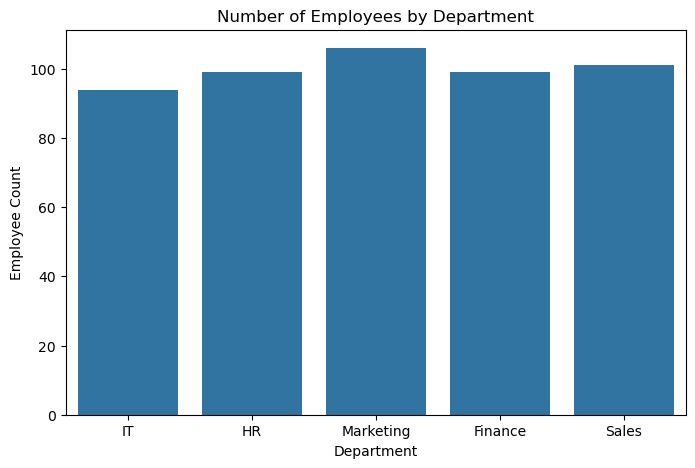

In [56]:
# countplot
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department"
)

plt.title("Number of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.show()

# Bivariate Analysis

## Objective

Bivariate Analysis is used to study the relationship between two variables. It helps us understand how one variable changes with respect to another and supports better business decision-making.

# charts used
scatterplot,barplot,boxplot


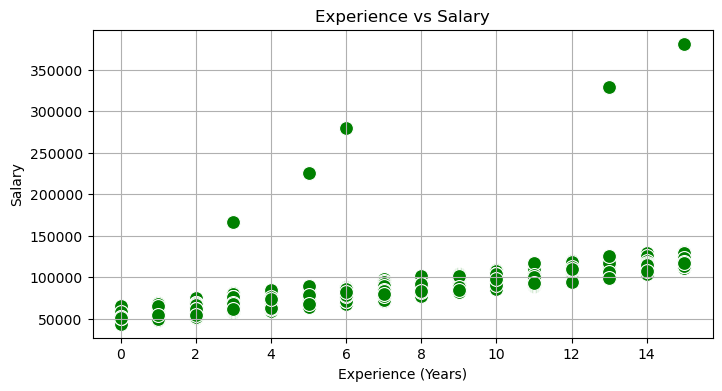

In [57]:
#  Experience vs Salary

plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x="Experience",y="Salary",color="green",s=100)
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

plt.grid(True)

plt.show()

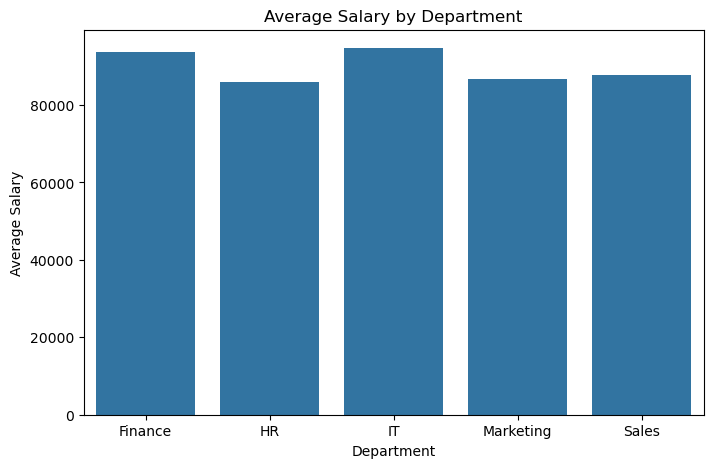

In [58]:
avg_salary = df.groupby("Department")["Salary"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_salary,
    x="Department",
    y="Salary"
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()

# Multivariate Analysis
## Objective

Multivariate Analysis is used to study the relationship among three or more variables simultaneously. 
# chart used
 heatmap,pairplot

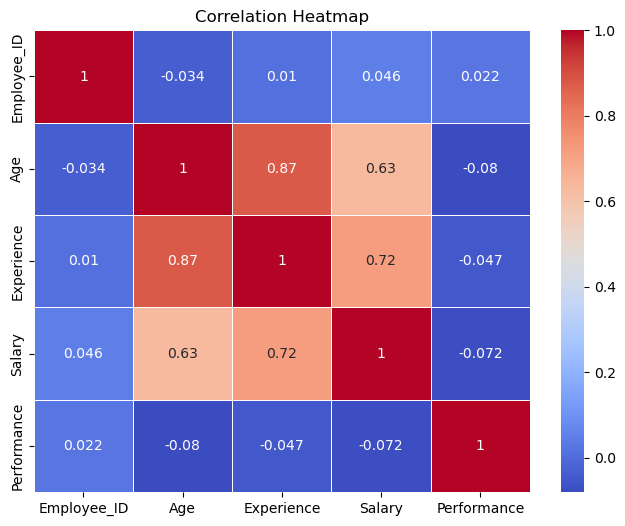

In [59]:
# Correlation analysis(heatmap)

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()


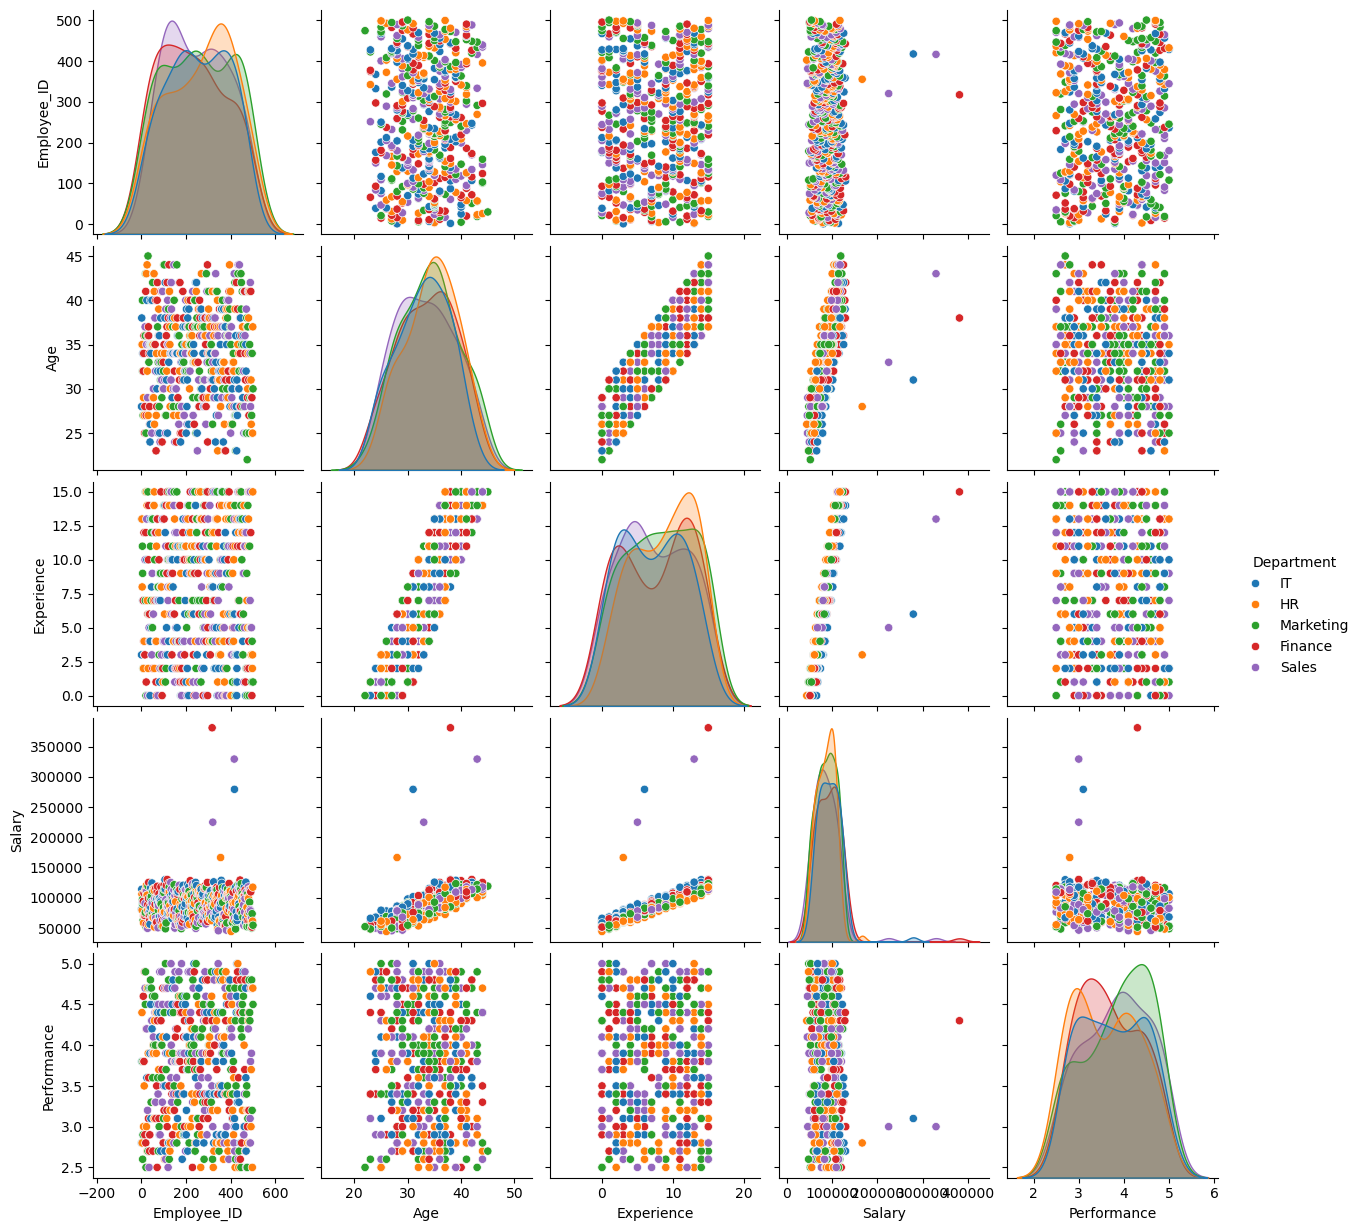

In [60]:
# pair plot

sns.pairplot(data=df,hue ="Department")

plt.show()

#  Business Insights

# Objective

The objective of this section is to summarize the key findings obtained from the data analysis. These insights help management understand employee trends and support better business decisions.
    
# 1. Salary Distribution

The histogram shows that most employees fall within a specific salary range, while only a few employees receive significantly higher salaries.
    
# 2. Salary Outliers

The box plot identified a few salary outliers. These values should be investigated to determine whether they represent senior employees or data entry errors.

# 3. Department-wise Employee Count

The count plot shows the distribution of employees across different departments. Some departments have significantly more employees than others.

# 4. Department-wise Average Salary

The bar plot indicates that the average salary differs across departments.

# 5. Experience vs Salary

The scatter plot and correlation analysis show that employee experience has a strong positive relationship with salary.

# 6. Correlation Analysis

The correlation heatmap indicates that Experience and Salary have a strong positive correlation, suggesting that experienced employees generally receive higher salaries.

#  Recommendations

# Recommendation 1

The company should periodically review salary structures across all departments to ensure fair compensation.

# Recommendation 3

The organization should continue rewarding experienced employees while providing career growth opportunities for less experienced staff.

# Recommendation 4

Departments with a high number of employees should receive adequate workforce planning and resource allocation.

# Recommendation 5

Regular employee data analysis should be performed to monitor salary trends, workforce distribution, and organizational growth.
   

# Conclusion

This Employee Data Analysis project explored employee salary, experience, department, and age using Python, Pandas, Matplotlib, and Seaborn.

The project included data understanding, data cleaning, univariate analysis, bivariate analysis, multivariate analysis, and correlation analysis. Based on these analyses, several business insights and recommendations were generated to support data-driven decision-making.

This project demonstrates the complete Exploratory Data Analysis (EDA) workflow and highlights how visualization and statistical analysis can be used to solve real business problems.

    